# AgriSmart — ConvNeXt-Tiny Plant Disease Classifier (Kaggle Edition)

This notebook is adapted to run **directly on Kaggle** (no Kaggle-API download, no Google Drive) using two datasets added as Kaggle inputs:

- `hassanikram/my-dataset` → mounted at `/kaggle/input/datasets/hassanikram/my-dataset/MyDataset`
- `abdallahalidev/plantvillage-dataset` → mounted at `/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color`

**Target: 38 classes total**
- 35 classes come **only** from the Hassan Ikram `MyDataset` (the disease/healthy classes you listed, plus `Apple_Black_rot` which was added back in).
- 3 classes come **only** from PlantVillage: `Blueberry___healthy`, `Raspberry___healthy`, `Soybean___healthy`.

Make sure both datasets are attached to this notebook (Add Input → search each dataset slug) and that the **GPU accelerator** is turned on (Settings → Accelerator → GPU T4 x2 / P100).


In [4]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled. Go to Settings -> Accelerator and turn on a GPU.")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 0. Configuration

All paths, seeds and global constants live here. Nothing outside this cell should hardcode a path.

In [5]:
import os
import random
import numpy as np
import torch

# ------------------------------------------------------------
# DATASET INPUT PATHS (read-only, provided by you)
# ------------------------------------------------------------

MY_DATASET   = "/kaggle/input/datasets/hassanikram/my-dataset/MyDataset"
PLANTVILLAGE = "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

# ------------------------------------------------------------
# WRITABLE OUTPUT PATHS (Kaggle only lets you write to /kaggle/working)
# ------------------------------------------------------------

WORKING_DIR     = "/kaggle/working"
METADATA_DIR    = os.path.join(WORKING_DIR, "agri_metadata")
SPLIT_DIR       = os.path.join(METADATA_DIR, "splits")
CHECKPOINT_DIR  = os.path.join(WORKING_DIR, "agri_checkpoints")

os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# MODEL / TRAINING CONFIG
# ------------------------------------------------------------

IMAGE_SIZE   = 224
BATCH_SIZE   = 32
NUM_WORKERS  = 2          # set to 0 if you see DataLoader worker crashes on Kaggle

STAGE1_EPOCHS = 3
STAGE2_EPOCHS = 8

STAGE1_LR    = 1e-3       # classifier head only (stage 1)
HEAD_LR      = 3e-4       # classifier head (stage 2)
BACKBONE_LR  = 3e-5       # backbone (stage 2)

WEIGHT_DECAY   = 1e-4
MAX_GRAD_NORM  = 1.0
PATIENCE       = 3        # early-stopping patience, in epochs, per stage

USE_AMP = torch.cuda.is_available()

print("Device        :", DEVICE)
print("MY_DATASET    :", MY_DATASET, "| exists:", os.path.isdir(MY_DATASET))
print("PLANTVILLAGE  :", PLANTVILLAGE, "| exists:", os.path.isdir(PLANTVILLAGE))
print("Working dir   :", WORKING_DIR)
print("Checkpoints   :", CHECKPOINT_DIR)


Device        : cuda
MY_DATASET    : /kaggle/input/datasets/hassanikram/my-dataset/MyDataset | exists: True
PLANTVILLAGE  : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color | exists: True
Working dir   : /kaggle/working
Checkpoints   : /kaggle/working/agri_checkpoints


### Quick look at what's actually on disk

Useful the first time you run this: confirms the two input paths are correct before anything else depends on them.

In [6]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_class_folders(root):
    if not os.path.isdir(root):
        return []
    return sorted([
        d for d in os.listdir(root)
        if os.path.isdir(os.path.join(root, d))
    ])

hassan_folders_on_disk = list_class_folders(MY_DATASET)
pv_folders_on_disk = list_class_folders(PLANTVILLAGE)

print("=" * 70)
print(f"HASSAN MyDataset — {len(hassan_folders_on_disk)} folders found")
print("=" * 70)
for f in hassan_folders_on_disk:
    print(" ", f)

print()
print("=" * 70)
print(f"PLANTVILLAGE color — {len(pv_folders_on_disk)} folders found")
print("=" * 70)
for f in pv_folders_on_disk[:10]:
    print(" ", f)
if len(pv_folders_on_disk) > 10:
    print(f"  ... and {len(pv_folders_on_disk) - 10} more")


HASSAN MyDataset — 45 folders found
  Apple_Black_rot
  Apple_Cedar_apple_rust
  Apple_Powdery_mildew
  Apple_healthy
  Apple_scab
  Cherry_(including_sour)_Powdery_mildew
  Cherry_(including_sour)_healthy
  Corn_(maize)_Cercospora_leaf_spot Gray_leaf_spot
  Corn_(maize)_Common_rust
  Corn_(maize)_Northern_Leaf_Blight
  Corn_(maize)_healthy
  Cotton_leaf_diseased
  Cotton_leaf_fresh
  Grape_Black_rot
  Grape___Esca_(Black_Measles)
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  Grape___healthy
  Orange_Haunglongbing_(Citrus_greening)
  Orange__Black_Rot
  Orange__Canker
  Orange__Healthy
  Peach_Bacterial_spot
  Peach_healthy
  Pepper,_bell_Bacterial_spot
  Pepper,_bell_healthy
  Potato_Early_blight
  Potato_Late_blight
  Potato_healthy
  Random
  Squash_Powdery_mildew
  Strawberry_Leaf_scorch
  Strawberry_healthy
  Tomato_Bacterial_spot
  Tomato_Early_blight
  Tomato_Late_blight
  Tomato_Leaf_Mold
  Tomato_Septoria_leaf_spot
  Tomato_Spider_mites_Two_spotted_spider_mite
  Tomato_Target

## 1. Define the 38 target classes

`HASSAN_TO_CANONICAL` maps every raw Hassan folder name to a canonical class name (using PlantVillage's `Genus___condition` naming convention). `PV_DIRECT_CLASSES` maps the 3 PlantVillage-only folders straight through.

Folder-name matching below is **not** purely exact-string: if a folder on disk doesn't match a key exactly (extra space, trailing underscore, different punctuation — PlantVillage folders are notorious for this, e.g. `Corn_(maize)___Common_rust_` with a trailing underscore), it falls back to a normalized comparison (lowercased, non-alphanumeric characters stripped) so small formatting differences don't silently drop a whole class. Anything that still doesn't match gets printed out explicitly so you can fix it by hand.

In [7]:
# ============================================================
# HASSAN MyDataset -> canonical class name
# (35 classes: the list you gave me, plus Apple_Black_rot)
# ============================================================

HASSAN_TO_CANONICAL = {
    "Apple_Black_rot": "Apple___Black_rot",
    "Apple_Cedar_apple_rust": "Apple___Cedar_apple_rust",
    "Apple_healthy": "Apple___healthy",
    "Apple_scab": "Apple___Apple_scab",

    "Cherry_(including_sour)_Powdery_mildew": "Cherry_(including_sour)___Powdery_mildew",
    "Cherry_(including_sour)_healthy": "Cherry_(including_sour)___healthy",

    "Corn_(maize)_Cercospora_leaf_spot Gray_leaf_spot": "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn_(maize)_Common_rust": "Corn_(maize)___Common_rust",
    "Corn_(maize)_Northern_Leaf_Blight": "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)_healthy": "Corn_(maize)___healthy",

    "Grape_Black_rot": "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)": "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)": "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy": "Grape___healthy",

    "Orange_Haunglongbing_(Citrus_greening)": "Orange___Haunglongbing_(Citrus_greening)",

    "Peach_Bacterial_spot": "Peach___Bacterial_spot",
    "Peach_healthy": "Peach___healthy",

    "Pepper,_bell_Bacterial_spot": "Pepper,_bell___Bacterial_spot",
    "Pepper,_bell_healthy": "Pepper,_bell___healthy",

    "Potato_Early_blight": "Potato___Early_blight",
    "Potato_Late_blight": "Potato___Late_blight",
    "Potato_healthy": "Potato___healthy",

    "Squash_Powdery_mildew": "Squash___Powdery_mildew",

    "Strawberry_Leaf_scorch": "Strawberry___Leaf_scorch",
    "Strawberry_healthy": "Strawberry___healthy",

    "Tomato_Bacterial_spot": "Tomato___Bacterial_spot",
    "Tomato_Early_blight": "Tomato___Early_blight",
    "Tomato_Late_blight": "Tomato___Late_blight",
    "Tomato_Leaf_Mold": "Tomato___Leaf_Mold",
    "Tomato_Septoria_leaf_spot": "Tomato___Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite": "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato_Target_Spot": "Tomato___Target_Spot",
    "Tomato_Tomato_Yellow_Leaf_Curl_Virus": "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato_Tomato_mosaic_virus": "Tomato___Tomato_mosaic_virus",
    "Tomato_healthy": "Tomato___healthy",
}

# ============================================================
# PLANTVILLAGE -> canonical class name
# (3 extra healthy classes, taken ONLY from PlantVillage)
# ============================================================

PV_DIRECT_CLASSES = {
    "Blueberry___healthy": "Blueberry___healthy",
    "Raspberry___healthy": "Raspberry___healthy",
    "Soybean___healthy": "Soybean___healthy",
}

# ============================================================
# FINAL CLASS LIST (order preserved, duplicates removed)
# ============================================================

CLASS_NAMES = list(dict.fromkeys(
    list(HASSAN_TO_CANONICAL.values()) + list(PV_DIRECT_CLASSES.values())
))

NUM_CLASSES = len(CLASS_NAMES)

assert len(CLASS_NAMES) == len(set(CLASS_NAMES)), "Duplicate canonical class names detected!"
assert NUM_CLASSES == 38, f"Expected 38 classes, got {NUM_CLASSES}"

CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

print("Total classes:", NUM_CLASSES)
for i, name in enumerate(CLASS_NAMES):
    print(f"{i:2d}  {name}")


Total classes: 38
 0  Apple___Black_rot
 1  Apple___Cedar_apple_rust
 2  Apple___healthy
 3  Apple___Apple_scab
 4  Cherry_(including_sour)___Powdery_mildew
 5  Cherry_(including_sour)___healthy
 6  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 7  Corn_(maize)___Common_rust
 8  Corn_(maize)___Northern_Leaf_Blight
 9  Corn_(maize)___healthy
10  Grape___Black_rot
11  Grape___Esca_(Black_Measles)
12  Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
13  Grape___healthy
14  Orange___Haunglongbing_(Citrus_greening)
15  Peach___Bacterial_spot
16  Peach___healthy
17  Pepper,_bell___Bacterial_spot
18  Pepper,_bell___healthy
19  Potato___Early_blight
20  Potato___Late_blight
21  Potato___healthy
22  Squash___Powdery_mildew
23  Strawberry___Leaf_scorch
24  Strawberry___healthy
25  Tomato___Bacterial_spot
26  Tomato___Early_blight
27  Tomato___Late_blight
28  Tomato___Leaf_Mold
29  Tomato___Septoria_leaf_spot
30  Tomato___Spider_mites Two-spotted_spider_mite
31  Tomato___Target_Spot
32  Tomato___T

## 2. Build the image metadata dataframe

Each Hassan folder is only used for the 35 Hassan classes; each PlantVillage folder is only used for the 3 PlantVillage-only classes. There is no merging of the two sources for the same class, so no cross-source deduplication is needed.

In [8]:
import re
import pandas as pd

def normalize(name: str) -> str:
    """Lowercase and strip everything that isn't a letter or digit,
    so 'Corn_(maize)___Common_rust_' and 'Corn (maize) Common rust'
    compare equal."""
    return re.sub(r"[^a-z0-9]+", "", name.lower())


def match_folder(folder_name: str, mapping: dict):
    """Exact match first, then a normalized fallback match."""
    if folder_name in mapping:
        return mapping[folder_name]

    target = normalize(folder_name)
    for key, canonical in mapping.items():
        if normalize(key) == target:
            return canonical

    return None


def collect_images(root_dir: str, mapping: dict, source_name: str):
    records = []
    unmatched_folders = []

    if not os.path.isdir(root_dir):
        print(f"WARNING: directory not found: {root_dir}")
        return pd.DataFrame(records, columns=["image_path", "label", "source"]), unmatched_folders

    actual_folders = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])

    for folder in actual_folders:
        canonical = match_folder(folder, mapping)

        if canonical is None:
            unmatched_folders.append(folder)
            continue

        folder_path = os.path.join(root_dir, folder)

        for fname in os.listdir(folder_path):
            if os.path.splitext(fname)[1].lower() in IMAGE_EXTENSIONS:
                records.append({
                    "image_path": os.path.join(folder_path, fname),
                    "label": canonical,
                    "source": source_name,
                })

    return pd.DataFrame(records, columns=["image_path", "label", "source"]), unmatched_folders


hassan_df, hassan_unmatched = collect_images(MY_DATASET, HASSAN_TO_CANONICAL, "Hassan")
pv_df, pv_unmatched = collect_images(PLANTVILLAGE, PV_DIRECT_CLASSES, "PlantVillage")

print("=" * 70)
print("COLLECTION RESULTS")
print("=" * 70)
print("Hassan images found     :", len(hassan_df))
print("PlantVillage images found:", len(pv_df))

if hassan_unmatched:
    print("\nHassan folders that did NOT match any target class (ignored):")
    for f in hassan_unmatched:
        print("  -", f)

if pv_unmatched:
    print("\nPlantVillage folders that did NOT match Blueberry/Raspberry/Soybean (ignored, expected — PlantVillage has 38 folders total):")
    print(" ", len(pv_unmatched), "folders skipped")

df = pd.concat([hassan_df, pv_df], ignore_index=True)

print("\nTotal combined images:", len(df))
print("Classes represented   :", df["label"].nunique(), "/", NUM_CLASSES)

missing_classes = set(CLASS_NAMES) - set(df["label"])
if missing_classes:
    print("\n*** WARNING: no images found at all for these classes: ***")
    for c in sorted(missing_classes):
        print("  -", c)
else:
    print("\nEvery target class has at least one image ✓")


COLLECTION RESULTS
Hassan images found     : 63549
PlantVillage images found: 6963

Hassan folders that did NOT match any target class (ignored):
  - Apple_Powdery_mildew
  - Cotton_leaf_diseased
  - Cotton_leaf_fresh
  - Orange__Black_Rot
  - Orange__Canker
  - Orange__Healthy
  - Random
  - Wheat_healthy
  - Wheat_leaf_rust
  - Wheat_nitrogen_deficiency

PlantVillage folders that did NOT match Blueberry/Raspberry/Soybean (ignored, expected — PlantVillage has 38 folders total):
  35 folders skipped

Total combined images: 70512
Classes represented   : 38 / 38

Every target class has at least one image ✓


## 3. Data quality checks

Drop unreadable/corrupted images, then drop exact-duplicate image files (same content, via MD5) keeping the first occurrence.

In [9]:
from PIL import Image
from tqdm.auto import tqdm

bad_rows = []

for idx, path in enumerate(tqdm(df["image_path"], desc="Verifying images")):
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception as e:
        bad_rows.append(idx)

print("Corrupted / unreadable images:", len(bad_rows))

if bad_rows:
    df = df.drop(index=bad_rows).reset_index(drop=True)
    print("Remaining images after removing corrupted files:", len(df))


Verifying images:   0%|          | 0/70512 [00:00<?, ?it/s]

Corrupted / unreadable images: 0


In [10]:
import hashlib

def file_md5(path, chunk_size=1024 * 1024):
    md5 = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            md5.update(chunk)
    return md5.hexdigest()

print("Hashing images to find exact duplicates...")

hashes = [file_md5(p) for p in tqdm(df["image_path"], desc="Hashing")]
df["md5"] = hashes

before = len(df)
df = df.drop_duplicates(subset=["md5"], keep="first").reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} exact-duplicate images ({before} -> {after})")


Hashing images to find exact duplicates...


Hashing:   0%|          | 0/70512 [00:00<?, ?it/s]

Removed 22 exact-duplicate images (70512 -> 70490)


In [11]:
MASTER_CSV = os.path.join(METADATA_DIR, "master_38_classes.csv")
df.to_csv(MASTER_CSV, index=False)

print("Saved master metadata CSV:", MASTER_CSV)
print("Total images:", len(df))
print("Total classes:", df["label"].nunique())

print("\nClass distribution:")
print(df["label"].value_counts().sort_index().to_string())


Saved master metadata CSV: /kaggle/working/agri_metadata/master_38_classes.csv
Total images: 70490
Total classes: 38

Class distribution:
label
Apple___Apple_scab                                    5456
Apple___Black_rot                                     3801
Apple___Cedar_apple_rust                              2193
Apple___healthy                                       6257
Blueberry___healthy                                   1502
Cherry_(including_sour)___Powdery_mildew              1057
Cherry_(including_sour)___healthy                      897
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     575
Corn_(maize)___Common_rust                            1295
Corn_(maize)___Northern_Leaf_Blight                   1159
Corn_(maize)___healthy                                1162
Grape___Black_rot                                     1232
Grape___Esca_(Black_Measles)                          1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            1076
Grape___healthy               

## 4. Train / validation / test split (stratified 80 / 10 / 10)

In [12]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("=" * 70)
print("FINAL DATASET SPLIT")
print("=" * 70)
print(f"Total : {len(df)}")
print(f"Train : {len(train_df)} ({len(train_df) / len(df) * 100:.2f}%)")
print(f"Val   : {len(val_df)} ({len(val_df) / len(df) * 100:.2f}%)")
print(f"Test  : {len(test_df)} ({len(test_df) / len(df) * 100:.2f}%)")

missing_train = set(CLASS_NAMES) - set(train_df["label"])
missing_val = set(CLASS_NAMES) - set(val_df["label"])
missing_test = set(CLASS_NAMES) - set(test_df["label"])

print("\nClasses missing from Train:", missing_train or "none")
print("Classes missing from Val  :", missing_val or "none")
print("Classes missing from Test :", missing_test or "none")

train_df.to_csv(os.path.join(SPLIT_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(SPLIT_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(SPLIT_DIR, "test.csv"), index=False)

print("\nSplits saved to:", SPLIT_DIR)


FINAL DATASET SPLIT
Total : 70490
Train : 56392 (80.00%)
Val   : 7049 (10.00%)
Test  : 7049 (10.00%)

Classes missing from Train: none
Classes missing from Val  : none
Classes missing from Test : none

Splits saved to: /kaggle/working/agri_metadata/splits


In [13]:
split_distribution = pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts(),
}).fillna(0).astype(int)

split_distribution["Total"] = (
    split_distribution["Train"]
    + split_distribution["Validation"]
    + split_distribution["Test"]
)

print(split_distribution.sort_index().to_string())


                                                    Train  Validation  Test  Total
label                                                                             
Apple___Apple_scab                                   4365         546   545   5456
Apple___Black_rot                                    3041         380   380   3801
Apple___Cedar_apple_rust                             1754         220   219   2193
Apple___healthy                                      5006         625   626   6257
Blueberry___healthy                                  1202         150   150   1502
Cherry_(including_sour)___Powdery_mildew              846         106   105   1057
Cherry_(including_sour)___healthy                     718          89    90    897
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    460          58    57    575
Corn_(maize)___Common_rust                           1036         130   129   1295
Corn_(maize)___Northern_Leaf_Blight                   927         116   116   1159
Corn

## 5. PyTorch `Dataset` and image transforms

In [14]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.0), ratio=(0.90, 1.10)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transforms created.")


Transforms created.


In [15]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        label = CLASS_TO_IDX[row["label"]]
        return image, label


train_dataset = PlantDiseaseDataset(train_df, transform=train_transform)
val_dataset = PlantDiseaseDataset(val_df, transform=eval_transform)
test_dataset = PlantDiseaseDataset(test_df, transform=eval_transform)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))


Train dataset: 56392
Val dataset  : 7049
Test dataset : 7049


## 6. Class-balanced sampler and data loaders

In [16]:
train_labels = train_df["label"].map(CLASS_TO_IDX).values
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)

# Inverse square-root weighting: less aggressive than pure inverse-frequency
class_weights = 1.0 / np.sqrt(class_counts)
sample_weights = torch.DoubleTensor(class_weights[train_labels])

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_dataset),
    replacement=True,
)

print("Class balancing (train split):")
for idx, count in enumerate(class_counts):
    print(f"{idx:2d} | {CLASS_NAMES[idx]:55s} | n={count:5d} | weight={class_weights[idx]:.4f}")


Class balancing (train split):
 0 | Apple___Black_rot                                       | n= 3041 | weight=0.0181
 1 | Apple___Cedar_apple_rust                                | n= 1754 | weight=0.0239
 2 | Apple___healthy                                         | n= 5006 | weight=0.0141
 3 | Apple___Apple_scab                                      | n= 4365 | weight=0.0151
 4 | Cherry_(including_sour)___Powdery_mildew                | n=  846 | weight=0.0344
 5 | Cherry_(including_sour)___healthy                       | n=  718 | weight=0.0373
 6 | Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      | n=  460 | weight=0.0466
 7 | Corn_(maize)___Common_rust                              | n= 1036 | weight=0.0311
 8 | Corn_(maize)___Northern_Leaf_Blight                     | n=  927 | weight=0.0328
 9 | Corn_(maize)___healthy                                  | n=  930 | weight=0.0328
10 | Grape___Black_rot                                       | n=  986 | weight=0.0318
11 | Grape__

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))


Train batches: 1763
Val batches  : 221
Test batches : 221


In [18]:
# Sanity check - if this cell hangs or crashes with a DataLoader
# worker error, set NUM_WORKERS = 0 in the config cell and re-run
# from the "PyTorch Dataset and image transforms" section onward.

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel value range:", images.min().item(), "to", images.max().item())
print("Unique labels in this batch:", torch.unique(labels).tolist())


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Pixel value range: -3.959428071975708 to 4.165623664855957
Unique labels in this batch: [0, 2, 3, 4, 6, 10, 13, 14, 18, 20, 24, 25, 26, 28, 29, 30, 32, 36, 37]


## 7. Model — ConvNeXt-Tiny with a new 38-class head

In [19]:
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Architecture : ConvNeXt-Tiny")
print("Pretrained   : ImageNet")
print("Input size   :", IMAGE_SIZE)
print("Classes      :", NUM_CLASSES)
print("Classifier   :", in_features, "->", NUM_CLASSES)
print("Device       :", DEVICE)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 202MB/s]  


Architecture : ConvNeXt-Tiny
Pretrained   : ImageNet
Input size   : 224
Classes      : 38
Classifier   : 768 -> 38
Device       : cuda
Total params    : 27,849,350
Trainable params: 27,849,350


In [20]:
model.eval()
with torch.no_grad():
    sample_images, _ = next(iter(val_loader))
    sample_images = sample_images.to(DEVICE, non_blocking=True)
    sample_outputs = model(sample_images)

print("Input shape :", sample_images.shape)
print("Output shape:", sample_outputs.shape)
assert sample_outputs.shape == (sample_images.shape[0], NUM_CLASSES)
print("Forward pass successful ✓")


Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 38])
Forward pass successful ✓


## 8. Training utilities

Shared by both stages: loss, AMP scaler, metrics, one training/validation epoch, and checkpoint save/load.

In [21]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

print("Loss   :", criterion)
print("AMP    :", USE_AMP)


def calculate_metrics(all_labels, all_predictions):
    accuracy = accuracy_score(all_labels, all_predictions)
    macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_labels, all_predictions, average="weighted", zero_division=0)
    return accuracy, macro_f1, weighted_f1


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    running_loss = 0.0
    all_labels, all_predictions = [], []

    progress = tqdm(loader, desc="Train", leave=False, dynamic_ncols=True)

    for images, labels in progress:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

        progress.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    accuracy, macro_f1, weighted_f1 = calculate_metrics(all_labels, all_predictions)
    return epoch_loss, accuracy, macro_f1, weighted_f1


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels, all_predictions = [], []

    for images, labels in tqdm(loader, desc="Validate", leave=False, dynamic_ncols=True):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy, macro_f1, weighted_f1 = calculate_metrics(all_labels, all_predictions)
    return epoch_loss, accuracy, macro_f1, weighted_f1


def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, best_macro_f1, stage, history):
    checkpoint = {
        "epoch": epoch,
        "stage": stage,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "best_macro_f1": best_macro_f1,
        "history": history,
        "class_names": CLASS_NAMES,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and checkpoint.get("optimizer_state_dict") is not None:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    if scaler is not None and checkpoint.get("scaler_state_dict") is not None:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])

    return checkpoint


Loss   : CrossEntropyLoss()
AMP    : True


## 9. Stage 1 — freeze the backbone, train the classifier head

In [22]:
STAGE1_BEST = os.path.join(CHECKPOINT_DIR, "convnext_tiny_stage1_best.pth")
STAGE1_LATEST = os.path.join(CHECKPOINT_DIR, "convnext_tiny_stage1_latest.pth")

# Freeze everything, then unfreeze only the final linear layer
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier[2].parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Stage 1 trainable parameters:", f"{trainable_params:,}")

stage1_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=STAGE1_LR,
    weight_decay=WEIGHT_DECAY,
)

stage1_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    stage1_optimizer, T_max=STAGE1_EPOCHS, eta_min=1e-6
)

stage1_scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

stage1_history = []
best_stage1_macro_f1 = -1.0
stage1_patience_counter = 0


Stage 1 trainable parameters: 29,222


In [23]:
print("=" * 70)
print("STAGE 1 TRAINING")
print("=" * 70)

for epoch in range(1, STAGE1_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{STAGE1_EPOCHS}")

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model, train_loader, stage1_optimizer, criterion, DEVICE, scaler=stage1_scaler
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1 = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    stage1_scheduler.step()

    print(f"  Train | loss={train_loss:.4f} acc={train_acc:.4f} macroF1={train_macro_f1:.4f}")
    print(f"  Val   | loss={val_loss:.4f} acc={val_acc:.4f} macroF1={val_macro_f1:.4f}")

    stage1_history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_macro_f1": train_macro_f1,
        "val_loss": val_loss, "val_acc": val_acc, "val_macro_f1": val_macro_f1,
    })

    save_checkpoint(STAGE1_LATEST, model, stage1_optimizer, stage1_scheduler, stage1_scaler,
                     epoch, best_stage1_macro_f1, "stage1", stage1_history)

    if val_macro_f1 > best_stage1_macro_f1:
        best_stage1_macro_f1 = val_macro_f1
        stage1_patience_counter = 0
        save_checkpoint(STAGE1_BEST, model, stage1_optimizer, stage1_scheduler, stage1_scaler,
                         epoch, best_stage1_macro_f1, "stage1", stage1_history)
        print(f"  -> New best (macro F1={best_stage1_macro_f1:.4f}), checkpoint saved")
    else:
        stage1_patience_counter += 1
        print(f"  -> No improvement ({stage1_patience_counter}/{PATIENCE})")
        if stage1_patience_counter >= PATIENCE:
            print("  Early stopping stage 1.")
            break

print("\nStage 1 complete. Best macro F1:", best_stage1_macro_f1)


STAGE 1 TRAINING

Epoch 1/3


Train:   0%|          | 0/1763 [00:00<?, ?it/s]

Validate:   0%|          | 0/221 [00:00<?, ?it/s]

  Train | loss=1.1369 acc=0.8895 macroF1=0.8913
  Val   | loss=0.9584 acc=0.9413 macroF1=0.9346
  -> New best (macro F1=0.9346), checkpoint saved

Epoch 2/3


Train:   0%|          | 0/1763 [00:00<?, ?it/s]

Validate:   0%|          | 0/221 [00:00<?, ?it/s]

  Train | loss=0.9536 acc=0.9454 macroF1=0.9470
  Val   | loss=0.9369 acc=0.9455 macroF1=0.9431
  -> New best (macro F1=0.9431), checkpoint saved

Epoch 3/3


Train:   0%|          | 0/1763 [00:00<?, ?it/s]

Validate:   0%|          | 0/221 [00:00<?, ?it/s]

  Train | loss=0.9325 acc=0.9511 macroF1=0.9531
  Val   | loss=0.9185 acc=0.9523 macroF1=0.9464
  -> New best (macro F1=0.9464), checkpoint saved

Stage 1 complete. Best macro F1: 0.946411989997761


## 10. Stage 2 — full fine-tuning with differential learning rates

Loads the best Stage 1 checkpoint, unfreezes the whole network, and trains the backbone and head with different learning rates.

In [24]:
STAGE2_BEST = os.path.join(CHECKPOINT_DIR, "convnext_tiny_stage2_best.pth")
STAGE2_LATEST = os.path.join(CHECKPOINT_DIR, "convnext_tiny_stage2_latest.pth")

# Start Stage 2 from the best Stage 1 weights
load_checkpoint(STAGE1_BEST, model)
print("Loaded Stage 1 best checkpoint into the model.")

# Unfreeze everything
for param in model.parameters():
    param.requires_grad = True

head_params = list(model.classifier[2].parameters())
head_param_ids = {id(p) for p in head_params}
backbone_params = [p for p in model.parameters() if id(p) not in head_param_ids]

stage2_optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": BACKBONE_LR},
    {"params": head_params, "lr": HEAD_LR},
], weight_decay=WEIGHT_DECAY)

stage2_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    stage2_optimizer, T_max=STAGE2_EPOCHS, eta_min=1e-7
)

stage2_scaler = torch.amp.GradScaler("cuda") if USE_AMP else None

stage2_history = []
best_stage2_macro_f1 = -1.0
stage2_patience_counter = 0

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Stage 2 trainable parameters:", f"{trainable_params:,}", "(full model)")


Loaded Stage 1 best checkpoint into the model.
Stage 2 trainable parameters: 27,849,350 (full model)


In [25]:
print("=" * 70)
print("STAGE 2 TRAINING")
print("=" * 70)

for epoch in range(1, STAGE2_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{STAGE2_EPOCHS}")

    train_loss, train_acc, train_macro_f1, train_weighted_f1 = train_one_epoch(
        model, train_loader, stage2_optimizer, criterion, DEVICE, scaler=stage2_scaler
    )

    val_loss, val_acc, val_macro_f1, val_weighted_f1 = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    stage2_scheduler.step()

    print(f"  Train | loss={train_loss:.4f} acc={train_acc:.4f} macroF1={train_macro_f1:.4f}")
    print(f"  Val   | loss={val_loss:.4f} acc={val_acc:.4f} macroF1={val_macro_f1:.4f}")

    stage2_history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_acc": train_acc, "train_macro_f1": train_macro_f1,
        "val_loss": val_loss, "val_acc": val_acc, "val_macro_f1": val_macro_f1,
    })

    save_checkpoint(STAGE2_LATEST, model, stage2_optimizer, stage2_scheduler, stage2_scaler,
                     epoch, best_stage2_macro_f1, "stage2", stage2_history)

    if val_macro_f1 > best_stage2_macro_f1:
        best_stage2_macro_f1 = val_macro_f1
        stage2_patience_counter = 0
        save_checkpoint(STAGE2_BEST, model, stage2_optimizer, stage2_scheduler, stage2_scaler,
                         epoch, best_stage2_macro_f1, "stage2", stage2_history)
        print(f"  -> New best (macro F1={best_stage2_macro_f1:.4f}), checkpoint saved")
    else:
        stage2_patience_counter += 1
        print(f"  -> No improvement ({stage2_patience_counter}/{PATIENCE})")
        if stage2_patience_counter >= PATIENCE:
            print("  Early stopping stage 2.")
            break

print("\nStage 2 complete. Best macro F1:", best_stage2_macro_f1)


STAGE 2 TRAINING

Epoch 1/8


Train:   0%|          | 0/1763 [00:00<?, ?it/s]

Validate:   0%|          | 0/221 [00:00<?, ?it/s]

  Train | loss=0.8214 acc=0.9754 macroF1=0.9756
  Val   | loss=0.7684 acc=0.9791 macroF1=0.9710
  -> New best (macro F1=0.9710), checkpoint saved

Epoch 2/8


Train:   0%|          | 0/1763 [00:00<?, ?it/s]

...

Validate:   0%|          | 0/221 [00:00<?, ?it/s]

  Train | loss=0.6855 acc=0.9970 macroF1=0.9974
  Val   | loss=0.7154 acc=0.9867 macroF1=0.9814
  -> New best (macro F1=0.9814), checkpoint saved

Epoch 8/8


Train:   0%|          | 0/1763 [00:00<?, ?it/s]

Validate:   0%|          | 0/221 [00:00<?, ?it/s]

  Train | loss=0.6851 acc=0.9970 macroF1=0.9974
  Val   | loss=0.7144 acc=0.9871 macroF1=0.9806
  -> No improvement (1/3)

Stage 2 complete. Best macro F1: 0.9813932666259627


## 11. Final evaluation on the held-out test set

In [26]:
load_checkpoint(STAGE2_BEST, model)
print("Loaded Stage 2 best checkpoint for final evaluation.")

model.eval()
all_labels, all_predictions = [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

test_accuracy, test_macro_f1, test_weighted_f1 = calculate_metrics(all_labels, all_predictions)

print("=" * 70)
print("TEST SET RESULTS")
print("=" * 70)
print(f"Accuracy    : {test_accuracy:.4f}")
print(f"Macro F1    : {test_macro_f1:.4f}")
print(f"Weighted F1 : {test_weighted_f1:.4f}")

print("\nPer-class report:")
print(classification_report(
    all_labels, all_predictions,
    target_names=CLASS_NAMES, zero_division=0,
))


Loaded Stage 2 best checkpoint for final evaluation.


Testing:   0%|          | 0/221 [00:00<?, ?it/s]

TEST SET RESULTS
Accuracy    : 0.9889
Macro F1    : 0.9877
Weighted F1 : 0.9889

Per-class report:
                                                    precision    recall  f1-score   support

                                 Apple___Black_rot       0.98      1.00      0.99       380
                          Apple___Cedar_apple_rust       0.98      0.96      0.97       219
                                   Apple___healthy       0.98      0.99      0.98       626
                                Apple___Apple_scab       0.99      0.98      0.98       545
          Cherry_(including_sour)___Powdery_mildew       0.99      1.00      1.00       105
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00        90
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.95      0.98      0.97        57
                        Corn_(maize)___Common_rust       0.98      1.00      0.99       129
               Corn_(maize)___Northern_Leaf_Blight       0.99      0.97 

## 12. Save final artifacts

Everything under `/kaggle/working` is captured as this notebook's Output when you commit/save the version, so no Drive mount is needed.

In [27]:
import json as _json

FINAL_MODEL_PATH = os.path.join(WORKING_DIR, "agrismart_convnext_tiny_final.pth")

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "class_to_idx": CLASS_TO_IDX,
    "image_size": IMAGE_SIZE,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_macro_f1,
    "test_weighted_f1": test_weighted_f1,
}, FINAL_MODEL_PATH)

with open(os.path.join(WORKING_DIR, "class_names.json"), "w") as f:
    _json.dump(CLASS_NAMES, f, indent=2)

print("Saved final model to:", FINAL_MODEL_PATH)
print("Saved class list to  :", os.path.join(WORKING_DIR, "class_names.json"))

print("\nContents of", WORKING_DIR)
for root, dirs, files in os.walk(WORKING_DIR):
    for fname in files:
        fpath = os.path.join(root, fname)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"  {fpath}  ({size_mb:.1f} MB)")


Saved final model to: /kaggle/working/agrismart_convnext_tiny_final.pth
Saved class list to  : /kaggle/working/class_names.json

Contents of /kaggle/working
  /kaggle/working/class_names.json  (0.0 MB)
  /kaggle/working/agrismart_convnext_tiny_final.pth  (106.3 MB)
  /kaggle/working/.virtual_documents/__notebook_source__.ipynb  (0.0 MB)
  /kaggle/working/agri_checkpoints/convnext_tiny_stage2_best.pth  (318.9 MB)
  /kaggle/working/agri_checkpoints/convnext_tiny_stage2_latest.pth  (318.9 MB)
  /kaggle/working/agri_checkpoints/convnext_tiny_stage1_best.pth  (106.5 MB)
  /kaggle/working/agri_checkpoints/convnext_tiny_stage1_latest.pth  (106.5 MB)
  /kaggle/working/agri_metadata/master_38_classes.csv  (12.1 MB)
  /kaggle/working/agri_metadata/splits/val.csv  (1.2 MB)
  /kaggle/working/agri_metadata/splits/test.csv  (1.2 MB)
  /kaggle/working/agri_metadata/splits/train.csv  (9.7 MB)


In [32]:
# ============================================================
# Cross-dataset evaluation: test the trained model on PlantDoc
# ============================================================

import os, re
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. Point this at wherever PlantDoc is mounted/extracted.
#    Kaggle example: "/kaggle/input/plantdoc-dataset/PlantDoc-Dataset/test"
#    (PlantDoc ships its own train/test split folders — use "test")
# ------------------------------------------------------------
PLANTDOC_DIR = "/kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test"


# ------------------------------------------------------------
# 2. PlantDoc folder name -> your canonical training label.
#    Only include entries whose canonical name actually exists
#    in CLASS_TO_IDX. Add/remove lines to match your real 38 classes.
# ------------------------------------------------------------
PLANTDOC_TO_CANONICAL = {
    "Apple Scab Leaf":                     "Apple___Apple_scab",
    "Apple rust leaf":                     "Apple___Cedar_apple_rust",
    "Apple leaf":                           "Apple___healthy",
    "Cherry leaf":                          "Cherry_(including_sour)___healthy",
    "Corn Gray leaf spot":                  "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "Corn leaf blight":                     "Corn_(maize)___Northern_Leaf_Blight",
    "Corn rust leaf":                       "Corn_(maize)___Common_rust",
    "Peach leaf":                           "Peach___healthy",
    "Potato leaf early blight":             "Potato___Early_blight",
    "Potato leaf late blight":              "Potato___Late_blight",
    "Squash Powdery mildew leaf":           "Squash___Powdery_mildew",
    "Strawberry leaf":                      "Strawberry___healthy",
    "Tomato Early blight leaf":             "Tomato___Early_blight",
    "Tomato leaf bacterial spot":           "Tomato___Bacterial_spot",
    "Tomato leaf late blight":              "Tomato___Late_blight",
    "Tomato leaf mosaic virus":             "Tomato___Tomato_mosaic_virus",
    "Tomato leaf yellow virus":             "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato mold leaf":                     "Tomato___Leaf_Mold",
    "Tomato Septoria leaf spot":            "Tomato___Septoria_leaf_spot",
    "Tomato two spotted spider mites leaf":  "Tomato___Spider_mites Two-spotted_spider_mite",
    "grape leaf black rot":                 "Grape___Black_rot",
    "Blueberry leaf":                       "Blueberry___healthy",
    "Raspberry leaf":                       "Raspberry___healthy",
    "Soyabean leaf":                        "Soybean___healthy",
}

def normalize(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", name.lower())

def match_folder(folder_name, mapping):
    if folder_name in mapping:
        return mapping[folder_name]
    target = normalize(folder_name)
    for key, canonical in mapping.items():
        if normalize(key) == target:
            return canonical
    return None

# ------------------------------------------------------------
# 3. Walk PlantDoc, keep only images whose canonical label
#    exists in your model's CLASS_TO_IDX.
# ------------------------------------------------------------
records, skipped_folders, dropped_no_class = [], [], []

if not os.path.isdir(PLANTDOC_DIR):
    raise FileNotFoundError(f"PlantDoc path not found: {PLANTDOC_DIR}")

for folder in sorted(os.listdir(PLANTDOC_DIR)):
    folder_path = os.path.join(PLANTDOC_DIR, folder)
    if not os.path.isdir(folder_path):
        continue

    canonical = match_folder(folder, PLANTDOC_TO_CANONICAL)
    if canonical is None:
        skipped_folders.append(folder)
        continue
    if canonical not in CLASS_TO_IDX:
        dropped_no_class.append((folder, canonical))
        continue

    for fname in os.listdir(folder_path):
        if os.path.splitext(fname)[1].lower() in IMAGE_EXTENSIONS:
            records.append({
                "image_path": os.path.join(folder_path, fname),
                "label": canonical,
            })

plantdoc_df = pd.DataFrame(records)

print(f"PlantDoc images kept   : {len(plantdoc_df)}")
print(f"PlantDoc classes used  : {plantdoc_df['label'].nunique() if len(plantdoc_df) else 0}")
print(f"Folders with no mapping: {skipped_folders}")
print(f"Mapped but not in model's 38 classes: {dropped_no_class}")

if len(plantdoc_df) == 0:
    raise RuntimeError("No PlantDoc images matched your class set — check PLANTDOC_DIR and the mapping.")

# ------------------------------------------------------------
# 4. Dataset / loader (reuses your existing classes)
# ------------------------------------------------------------
plantdoc_dataset = PlantDiseaseDataset(plantdoc_df, transform=eval_transform)
plantdoc_loader = DataLoader(
    plantdoc_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# ------------------------------------------------------------
# 5. Load the trained checkpoint (skip this if `model` is
#    already loaded with STAGE2_BEST weights in the session)
# ------------------------------------------------------------
checkpoint = torch.load(FINAL_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

# ------------------------------------------------------------
# 6. Run inference
# ------------------------------------------------------------
all_labels, all_predictions = [], []

with torch.no_grad():
    for images, labels in tqdm(plantdoc_loader, desc="PlantDoc eval"):
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

pd_accuracy, pd_macro_f1, pd_weighted_f1 = calculate_metrics(all_labels, all_predictions)

print("=" * 70)
print("PLANTDOC (OUT-OF-DISTRIBUTION) TEST RESULTS")
print("=" * 70)
print(f"Accuracy    : {pd_accuracy:.4f}")
print(f"Macro F1    : {pd_macro_f1:.4f}")
print(f"Weighted F1 : {pd_weighted_f1:.4f}")

used_classes = sorted(plantdoc_df["label"].unique(), key=lambda c: CLASS_TO_IDX[c])
print("\nPer-class report (classes present in PlantDoc subset only):")
print(classification_report(
    all_labels, all_predictions,
    labels=[CLASS_TO_IDX[c] for c in used_classes],
    target_names=used_classes,
    zero_division=0,
))

PlantDoc images kept   : 199
PlantDoc classes used  : 23
Folders with no mapping: ['Bell_pepper leaf', 'Bell_pepper leaf spot', 'Tomato leaf', 'grape leaf']
Mapped but not in model's 38 classes: []


PlantDoc eval:   0%|          | 0/7 [00:00<?, ?it/s]

PLANTDOC (OUT-OF-DISTRIBUTION) TEST RESULTS
Accuracy    : 0.5276
Macro F1    : 0.3894
Weighted F1 : 0.5210

Per-class report (classes present in PlantDoc subset only):
                                                    precision    recall  f1-score   support

                          Apple___Cedar_apple_rust       0.56      1.00      0.71        10
                                   Apple___healthy       0.46      0.67      0.55         9
                                Apple___Apple_scab       0.57      0.40      0.47        10
                 Cherry_(including_sour)___healthy       0.86      0.60      0.71        10
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.10      0.25      0.14         4
                        Corn_(maize)___Common_rust       0.89      0.80      0.84        10
               Corn_(maize)___Northern_Leaf_Blight       0.56      0.42      0.48        12
                                 Grape___Black_rot       1.00      0.62      0.77         8
   

In [33]:
print(list(PLANTDOC_TO_CANONICAL.keys()))

['Apple Scab Leaf', 'Apple rust leaf', 'Apple leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'Tomato Septoria leaf spot', 'Tomato two spotted spider mites leaf', 'grape leaf black rot', 'Blueberry leaf', 'Raspberry leaf', 'Soyabean leaf']


In [34]:
for f in sorted(os.listdir(PLANTDOC_DIR)):
    if match_folder(f, PLANTDOC_TO_CANONICAL) is None:
        print(repr(f))

'Bell_pepper leaf'
'Bell_pepper leaf spot'
'Tomato leaf'
'grape leaf'


In [35]:
def match_folder_robust(folder_name, mapping):
    # exact / normalized match first (unchanged behavior)
    exact = match_folder(folder_name, mapping)
    if exact is not None:
        return exact

    # strip leading digits/underscores some Kaggle mirrors prepend, e.g. "0_Bell_pepper_leaf"
    stripped = re.sub(r"^[\d_]+", "", folder_name)
    exact = match_folder(stripped, mapping)
    if exact is not None:
        return exact

    return None

In [36]:
print(PLANTDOC_TO_CANONICAL.get("Tomato leaf"))
print(PLANTDOC_TO_CANONICAL.get("grape leaf"))
print(PLANTDOC_TO_CANONICAL.get("Bell_pepper leaf"))

None
None
None


In [37]:
PLANTDOC_TO_CANONICAL.update({
    "Bell_pepper leaf":       "Pepper,_bell___healthy",
    "Bell_pepper leaf spot":  "Pepper,_bell___Bacterial_spot",
    "Tomato leaf":            "Tomato___healthy",
    "grape leaf":             "Grape___healthy",
})

print(PLANTDOC_TO_CANONICAL.get("Tomato leaf"))  # should now print Tomato___healthy

Tomato___healthy


In [38]:
import os, re
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.metrics import classification_report, f1_score, accuracy_score
from tqdm.auto import tqdm
from PIL import Image

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

records, skipped_folders, dropped_no_class = [], [], []
for folder in sorted(os.listdir(PLANTDOC_DIR)):
    folder_path = os.path.join(PLANTDOC_DIR, folder)
    if not os.path.isdir(folder_path):
        continue
    canonical = match_folder(folder, PLANTDOC_TO_CANONICAL)
    if canonical is None:
        skipped_folders.append(folder)
        continue
    if canonical not in CLASS_TO_IDX:
        dropped_no_class.append((folder, canonical))
        continue
    for fname in os.listdir(folder_path):
        if os.path.splitext(fname)[1].lower() in IMAGE_EXTENSIONS:
            records.append({"image_path": os.path.join(folder_path, fname), "label": canonical})

plantdoc_df = pd.DataFrame(records)
print(f"PlantDoc images kept : {len(plantdoc_df)}")
print(f"Classes covered      : {plantdoc_df['label'].nunique() if len(plantdoc_df) else 0} / 38")
print(f"Unmapped folders     : {skipped_folders}")
print(f"Mapped but not in your 38 classes: {dropped_no_class}")
assert len(plantdoc_df) > 0, "No images matched."

IMAGE_SIZE = 224
eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, CLASS_TO_IDX[row["label"]]

plantdoc_loader = DataLoader(
    PlantDiseaseDataset(plantdoc_df, transform=eval_transform),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True,
)

model.eval()
all_labels, all_predictions = [], []
with torch.no_grad():
    for images, labels in tqdm(plantdoc_loader, desc="PlantDoc eval"):
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)
        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

used_classes = sorted(plantdoc_df["label"].unique(), key=lambda c: CLASS_TO_IDX[c])
used_label_ids = [CLASS_TO_IDX[c] for c in used_classes]

accuracy = accuracy_score(all_labels, all_predictions)
macro_f1 = f1_score(all_labels, all_predictions, average="macro", labels=used_label_ids, zero_division=0)
weighted_f1 = f1_score(all_labels, all_predictions, average="weighted", labels=used_label_ids, zero_division=0)

print("=" * 70)
print("PLANTDOC RESULTS — convnext_tiny_stage2_best (1).pth")
print("=" * 70)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Macro F1    : {macro_f1:.4f}")
print(f"Weighted F1 : {weighted_f1:.4f}")

print("\nPer-class report:")
print(classification_report(
    all_labels, all_predictions,
    labels=used_label_ids,
    target_names=used_classes,
    zero_division=0,
))

PlantDoc images kept : 236
Classes covered      : 27 / 38
Unmapped folders     : []
Mapped but not in your 38 classes: []


PlantDoc eval:   0%|          | 0/8 [00:00<?, ?it/s]

PLANTDOC RESULTS — convnext_tiny_stage2_best (1).pth
Accuracy    : 0.5551
Macro F1    : 0.5246
Weighted F1 : 0.5407

Per-class report:
                                                    precision    recall  f1-score   support

                          Apple___Cedar_apple_rust       0.56      1.00      0.71        10
                                   Apple___healthy       0.46      0.67      0.55         9
                                Apple___Apple_scab       0.50      0.40      0.44        10
                 Cherry_(including_sour)___healthy       0.67      0.60      0.63        10
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.10      0.25      0.14         4
                        Corn_(maize)___Common_rust       0.89      0.80      0.84        10
               Corn_(maize)___Northern_Leaf_Blight       0.56      0.42      0.48        12
                                 Grape___Black_rot       1.00      0.62      0.77         8
                                   G

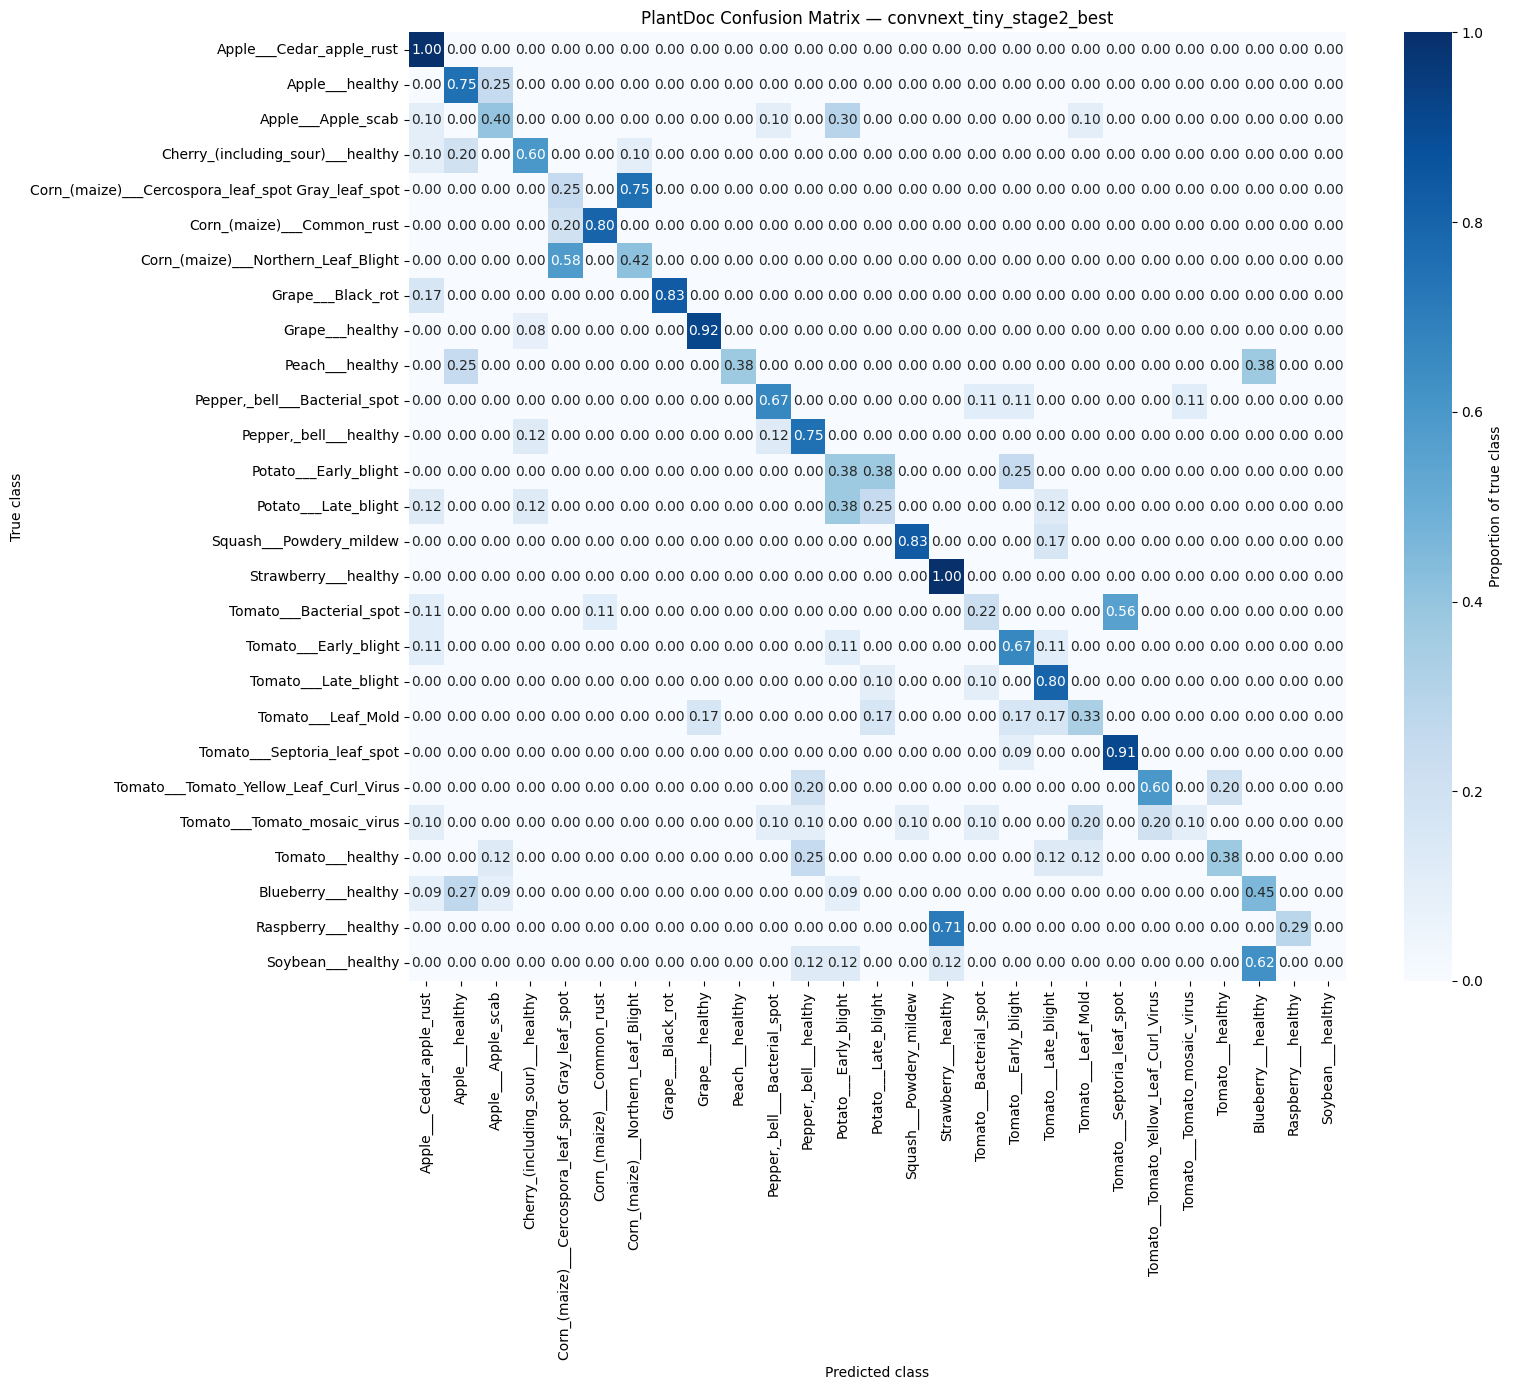

Saved to /kaggle/working/plantdoc_confusion_matrix.png


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions, labels=used_label_ids)

# Normalize by row (true class) so each row sums to 1 — easier to read
# than raw counts when classes have different support sizes
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)  # handles any zero-support rows

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_normalized,
    annot=True, fmt=".2f", cmap="Blues",
    xticklabels=used_classes, yticklabels=used_classes,
    cbar_kws={"label": "Proportion of true class"},
    ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("PlantDoc Confusion Matrix — convnext_tiny_stage2_best")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/plantdoc_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved to /kaggle/working/plantdoc_confusion_matrix.png")

In [42]:
%%writefile predict.py
"""
AgriSmart AI — Crop Disease Prediction (SIH 2026, Core Task)
Usage:
    python predict.py --image path/to/leaf.jpg
    python predict.py --image path/to/leaf.jpg --model path/to/model.pth
"""

import argparse
import os
import sys

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import convnext_tiny
from PIL import Image

SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
DEFAULT_MODEL_PATH = os.path.join(SCRIPT_DIR, "agrismart_convnext_tiny_final.pth")

IMAGE_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def load_model(model_path, device):
    if not os.path.isfile(model_path):
        raise FileNotFoundError(f"Model checkpoint not found at: {model_path}")

    checkpoint = torch.load(model_path, map_location=device)

    if "class_names" not in checkpoint:
        raise KeyError(
            "Checkpoint does not contain 'class_names'. "
            "Make sure you are using the FINAL packaged model, not a raw stage checkpoint."
        )

    class_names = checkpoint["class_names"]
    num_classes = len(class_names)

    model = convnext_tiny(weights=None)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    return model, class_names


def preprocess_image(image_path):
    if not os.path.isfile(image_path):
        raise FileNotFoundError(f"Image not found at: {image_path}")

    transform = transforms.Compose([
        transforms.Resize(int(IMAGE_SIZE * 1.14)),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0)


def predict(image_path, model_path=DEFAULT_MODEL_PATH):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model, class_names = load_model(model_path, device)
    image_tensor = preprocess_image(image_path).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = class_names[predicted_idx.item()]
    return predicted_class, confidence.item()


def main():
    parser = argparse.ArgumentParser(description="Predict crop disease from a leaf image")
    parser.add_argument("--image", required=True, help="Path to the leaf image file")
    parser.add_argument("--model", default=DEFAULT_MODEL_PATH, help="Path to the trained model checkpoint")
    args = parser.parse_args()

    try:
        predicted_class, confidence = predict(args.image, args.model)
    except (FileNotFoundError, KeyError) as e:
        print(f"Error: {e}", file=sys.stderr)
        sys.exit(1)

    print(f"Predicted class: {predicted_class}")
    print(f"Confidence: {confidence:.4f}")


if __name__ == "__main__":
    main()

Writing predict.py


In [43]:
!python predict.py --image /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test/"Apple leaf"/some_image.jpg --model /kaggle/working/agrismart_convnext_tiny_final.pth

Error: Image not found at: /kaggle/input/datasets/abdulhasibuddin/plant-doc-dataset/PlantDoc-Dataset/test/Apple leaf/some_image.jpg


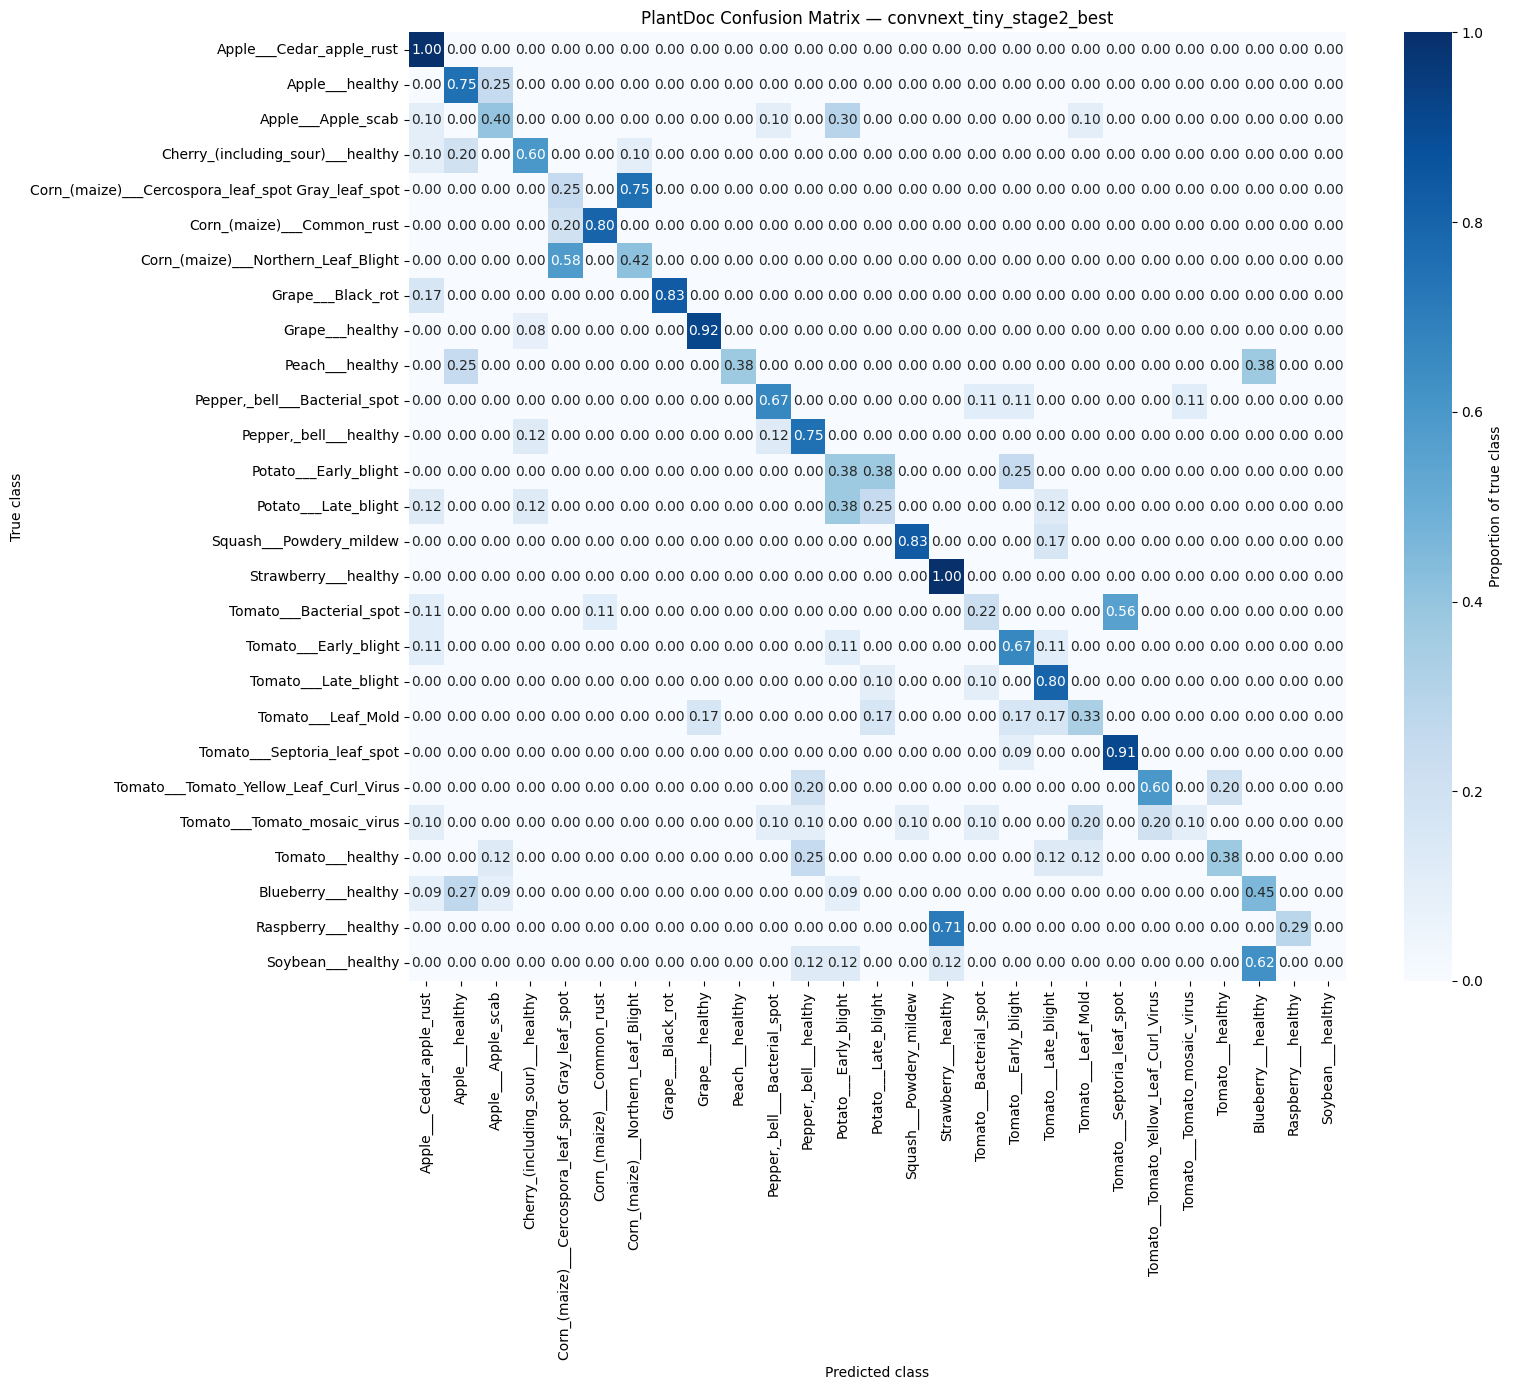

Saved: True


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions, labels=used_label_ids)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm_normalized, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=used_classes, yticklabels=used_classes,
    cbar_kws={"label": "Proportion of true class"}, ax=ax,
)
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_title("PlantDoc Confusion Matrix — convnext_tiny_stage2_best")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("/kaggle/working/plantdoc_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", os.path.exists("/kaggle/working/plantdoc_confusion_matrix.png"))

In [45]:
import os
import shutil
import zipfile

BUNDLE_DIR = "/kaggle/working/agrismart_submission_bundle"
os.makedirs(BUNDLE_DIR, exist_ok=True)

# List every file you want in the bundle — adjust paths to match what
# actually exists in your /kaggle/working directory right now
files_to_bundle = [
    "/kaggle/working/agrismart_convnext_tiny_final.pth",
    "/kaggle/working/class_names.json",
    "/kaggle/working/plantdoc_confusion_matrix.png",
    "/kaggle/working/predict (1).py",   # rename to predict.py before final repo commit
]

missing = []
for f in files_to_bundle:
    if os.path.isfile(f):
        shutil.copy(f, BUNDLE_DIR)
    else:
        missing.append(f)

if missing:
    print("WARNING — these files were not found and were skipped:")
    for f in missing:
        print(" -", f)

# Zip the bundle directory
zip_path = "/kaggle/working/agrismart_submission_bundle.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(BUNDLE_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, BUNDLE_DIR)
            zf.write(file_path, arcname)

print(f"\nZip created at: {zip_path}")
print(f"Size: {os.path.getsize(zip_path) / (1024*1024):.2f} MB")
print("\nContents:")
with zipfile.ZipFile(zip_path, "r") as zf:
    for name in zf.namelist():
        print(" -", name)

WARNING — these files were not found and were skipped:
 - /kaggle/working/predict (1).py

Zip created at: /kaggle/working/agrismart_submission_bundle.zip
Size: 99.11 MB

Contents:
 - class_names.json
 - plantdoc_confusion_matrix.png
 - agrismart_convnext_tiny_final.pth


In [47]:
  %run "/kaggle/working/predict.py" --image dummy  # will error on missing dummy file, but loads the functions

usage: predict.py [-h] --image IMAGE [--model MODEL]
predict.py: error: unrecognized arguments: # will error on missing dummy file, but loads the functions


SystemExit: 2

<Figure size 640x480 with 0 Axes>

In [61]:
url='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTxChA4xyqxCr_qjjcdwN4zJX9SSNBiu2anB1M7fHZsQg&s=10'

Downloaded to: /kaggle/working/downloaded_leaf.jpg


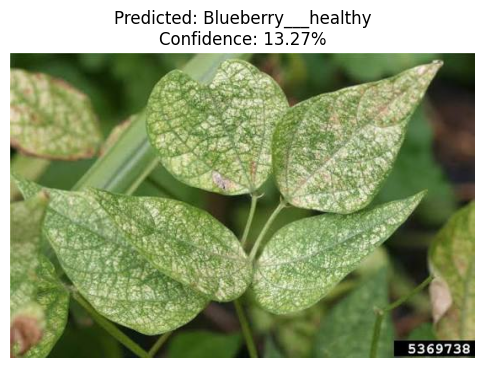

In [93]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Download the image from a URL
# ------------------------------------------------------------
image_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQ80ZciqWWfcP-PyaQuQmshKt1TaQquGwWblTywsVgKtg&s=10'
response = requests.get(image_url, timeout=10)
response.raise_for_status()  # errors out clearly if the link is broken/inaccessible

save_path = "/kaggle/working/downloaded_leaf.jpg"
with open(save_path, "wb") as f:
    f.write(response.content)

print("Downloaded to:", save_path)

# ------------------------------------------------------------
# 2. Run prediction (assumes predict() is already defined/imported)
# ------------------------------------------------------------
predicted_class, confidence = predict(save_path, model_path="/kaggle/working/agrismart_convnext_tiny_final.pth")

# ------------------------------------------------------------
# 3. Show the image + prediction together
# ------------------------------------------------------------
img = Image.open(save_path)
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2%}", fontsize=12)
plt.show()